# 10 — Análise de resolução de citações e desenho do Resolver

Experimento determinístico e *oracle-only*: cada span do goldenset é entregue ao `CitationParser` V1 e a resolução é estudada separadamente contra o corpus canônico. `classificacao` e `id_canonico` entram somente após a decisão experimental, como ground truth. Este notebook não altera componentes de produção, não usa FTS como identidade e não cria um resolver em `src`.

## 1. Setup, integridade e contrato do experimento

A família usada para exercitar o parser é derivada deterministicamente do span; o campo `tipo` apenas separa referências legais sem marcador lexical. Nenhuma estratégia lê `classificacao` ou `id_canonico`.

In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
import hashlib
from pathlib import Path
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.citations import CitationCandidate, CitationParser
from bracis_jusbrasil.database import connect_database, get_database_path

pd.set_option('display.max_colwidth', 120)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
TEXT_DIR = DATASET_DIR / 'txt'
GOLDENSET_PATH = DATASET_DIR / 'goldenset.xlsx'
DB_PATH = DATASET_DIR / 'desafio1_bracis.db'
EXPECTED_HASH = 'd759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'

assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest() == EXPECTED_HASH
with connect_database(get_database_path(), read_only=True) as connection:
    assert connection.execute('PRAGMA integrity_check').fetchone()[0] == 'ok'
print('SHA-256 e PRAGMA integrity_check confirmados; SQLite será usado somente em read-only.')

SHA-256 e PRAGMA integrity_check confirmados; SQLite será usado somente em read-only.


## 2. Dataset, corpus, schema e IDs reais

Antes de propor lookup para súmulas ou dispositivos, o schema é inspecionado. O registry de `id_canonico` é construído somente depois para avaliação; ele não participa da construção de candidatos.

In [2]:
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl').copy()
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
assert len(texts) == 26 and len(gold) == 225
# O Excel representa LF como os dois caracteres literais \n; o span canônico é sempre o recorte do .txt.
assert all(texts[row.documento_id][int(row.inicio):int(row.fim)] == row.trecho.replace('\\n', '\n') for row in gold.itertuples())
assert gold['classificacao'].value_counts().to_dict() == {'real': 96, 'incompleta': 65, 'inventada': 64}
assert gold['tipo'].value_counts().to_dict() == {'jurisprudencia': 186, 'lei': 39}

with connect_database(get_database_path(), read_only=True) as connection:
    schema = pd.DataFrame(connection.execute("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").fetchall(), columns=['table'])
    document_columns = pd.DataFrame(connection.execute('PRAGMA table_info(documentos)').fetchall(), columns=['cid', 'column', 'type', 'notnull', 'default', 'pk'])
    records = pd.DataFrame([dict(row) for row in connection.execute('SELECT documento_id, id, tribunal, ano, relator, natureza, tipo, texto FROM documentos ORDER BY id').fetchall()])
    index = build_case_index(connection)

records['id'] = records['id'].astype(int)
corpus_table = records.groupby('natureza', as_index=False).agg(records=('id', 'size'), **{'canonical IDs': ('id', 'nunique')})
real_gold = gold.loc[gold['classificacao'].eq('real')].copy()
assert real_gold['id_canonico'].notna().sum() == 96
assert all(not isinstance(value, (list, set, tuple, dict)) for value in real_gold['id_canonico'])
real_gold['id_canonico'] = real_gold['id_canonico'].astype(int)
id_registry = records.set_index('id')['natureza'].to_dict()  # avaliação apenas
assert real_gold['id_canonico'].isin(id_registry).all()
real_type_table = (real_gold.assign(record_type=real_gold['id_canonico'].map(id_registry))
                   .groupby('record_type', as_index=False)
                   .agg(**{'real citations': ('citacao_id', 'size'), 'distinct canonical IDs': ('id_canonico', 'nunique')}))

print('Dataset:', len(texts), 'documentos;', len(gold), 'citações; spans válidos:', len(gold), '/', len(gold))
display(corpus_table.rename(columns={'natureza': 'record_type'}))
display(real_type_table)
print('Tabelas SQLite relevantes:')
display(schema)
print('Campos de documentos:')
display(document_columns[['column', 'type', 'pk']])

Dataset: 26 documentos; 225 citações; spans válidos: 225 / 225


,record_type,records,canonical IDs
0,acordao,998,998
1,dispositivo,13,13
2,sumula,5,5


,record_type,real citations,distinct canonical IDs
0,acordao,77,77
1,dispositivo,14,13
2,sumula,5,5


Tabelas SQLite relevantes:


,table
0,documentos
1,documentos_fts
2,documentos_fts_config
3,documentos_fts_data
4,documentos_fts_docsize
5,documentos_fts_idx


Campos de documentos:


,column,type,pk
0,documento_id,TEXT,1
1,id,INTEGER,0
2,tribunal,TEXT,0
3,ano,INTEGER,0
4,relator,TEXT,0
5,natureza,TEXT,0
6,tipo,TEXT,0
7,texto,TEXT,0
8,texto_len,INTEGER,0


## 3. Parser-oráculo, índices em memória e `ResolutionProbe` local

A suficiência é decidida pela estrutura do `ParsedCitation` antes da consulta. O probe preserva todos os `candidate_ids`; quando há mais de um, o resultado é `ambiguous`, nunca uma escolha posicional.

In [3]:
CNJ = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
SUMULA = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I)
ARTICLE = re.compile(r'\b(?:art(?:igo)?s?[.]?\s*)\d+', re.I)
DIPLOMA = re.compile(r'\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b', re.I)
PROCESS_CLASS = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
TRIBUNAL = re.compile(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b', re.I)
YEAR = re.compile(r'\b(?:19\d{2}|20\d{2})\b')
RELATOR = re.compile(r'\b(?:Rel\.?|Relator(?:a)?)\s*(?:Min\.?|Ministra|Ministro|Des\.?)?\s*[A-Z]', re.I)

def family_for_parser(span: str, citation_type: str) -> str:
    if citation_type == 'lei':
        if ARTICLE.search(span) and DIPLOMA.search(span):
            return 'lei_dispositivo_com_diploma'
        if ARTICLE.search(span):
            return 'lei_dispositivo_sem_diploma'
        return 'lei_referencia_geral'
    if SUMULA.search(span):
        return 'sumula_numerada'
    if CNJ.search(span):
        return 'processo_cnj'
    if PROCESS_CLASS.search(span) and re.search(r'\d', span):
        return 'processo_ou_recurso_numerado'
    if TRIBUNAL.search(span) and (YEAR.search(span) or RELATOR.search(span)):
        return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'

@dataclass(frozen=True)
class ResolutionProbe:
    status: str
    candidate_ids: tuple[int, ...]
    id_canonico: int | None
    strategy: str
    reason: str

case_by_number: dict[str, set[int]] = defaultdict(set)
case_by_tribunal_number = {}
for case in index.cases():
    case_by_number[case.numero_normalizado].update(case.canonical_ids)
    case_by_tribunal_number[(case.tribunal, case.numero_normalizado)] = case

sumula_by_number: dict[str, set[int]] = defaultdict(set)
sumula_by_tribunal_number: dict[tuple[str, str], set[int]] = defaultdict(set)
article_by_number: dict[str, set[int]] = defaultdict(set)
for row in records.itertuples():
    if row.natureza == 'sumula':
        match = re.search(r'S[ÚU]MULA(?:\s+VINCULANTE)?\s+(\d+)', row.texto, re.I)
        if match:
            sumula_by_number[match.group(1)].add(row.id)
            sumula_by_tribunal_number[(row.tribunal, match.group(1))].add(row.id)
    elif row.natureza == 'dispositivo':
        match = re.match(r'Art[.]\s*(\d+)', row.texto, re.I)
        if match:
            article_by_number[match.group(1)].add(row.id)

def outcome(ids: tuple[int, ...], strategy: str, reason: str) -> ResolutionProbe:
    if not ids:
        return ResolutionProbe('no_match', (), None, strategy, reason)
    if len(ids) == 1:
        return ResolutionProbe('resolved_unique', ids, ids[0], strategy, reason)
    return ResolutionProbe('ambiguous', ids, None, strategy, reason)

def resolve_experimental(parsed, span: str) -> ResolutionProbe:
    data = parsed.data
    if parsed.family in {'processo_cnj', 'processo_ou_recurso_numerado'}:
        number = data.get('numero_normalizado')
        if not number:
            return ResolutionProbe('insufficient', (), None, 'none', 'missing_process_number')
        if parsed.tribunal:
            case = case_by_tribunal_number.get((parsed.tribunal, number))
            return outcome(tuple(case.canonical_ids) if case else (), 'tribunal_case_number', 'structured_process_number')
        return outcome(tuple(sorted(case_by_number.get(number, ()))), 'case_number_exact', 'structured_process_number')
    if parsed.family == 'sumula_numerada':
        number = data.get('sumula_numero')
        if not number:
            return ResolutionProbe('insufficient', (), None, 'none', 'missing_sumula_number')
        if not parsed.tribunal:
            return ResolutionProbe('insufficient', (), None, 'sumula_number_only', 'tribunal_required_for_semantic_sufficiency')
        return outcome(tuple(sorted(sumula_by_tribunal_number.get((parsed.tribunal, number), ()))), 'sumula_number_tribunal', 'number_and_tribunal')
    if parsed.family == 'lei_dispositivo_com_diploma':
        article = data.get('artigo')
        if not article or not data.get('diploma_normalizado'):
            return ResolutionProbe('insufficient', (), None, 'none', 'missing_legal_identifier')
        return outcome(tuple(sorted(article_by_number.get(article, ()))), 'legal_article_frozen_corpus', 'corpus_lacks_diploma_metadata')
    if parsed.family == 'lei_dispositivo_sem_diploma':
        return ResolutionProbe('insufficient', (), None, 'legal_article_only', 'diploma_required_for_semantic_sufficiency')
    if parsed.family == 'jurisprudencia_tribunal_contextual':
        return ResolutionProbe('insufficient', (), None, 'contextual_metadata', 'not_primary_identity')
    if parsed.family == 'jurisprudencia_referencia_geral':
        reason = 'parser_missing_identifier' if re.search(r'\d', span) else 'no_structured_identifier'
        return ResolutionProbe('insufficient', (), None, 'none', reason)
    return ResolutionProbe('insufficient', (), None, 'none', 'unsupported_family')

def build_results() -> pd.DataFrame:
    rows = []
    parser = CitationParser()
    for row in gold.itertuples():
        span = texts[row.documento_id][int(row.inicio):int(row.fim)]
        family = family_for_parser(span, row.tipo)
        parsed = parser.parse(CitationCandidate(0, len(span), span, 'oracle_span', family))
        probe = resolve_experimental(parsed, span)
        rows.append({
            'nivel': f'N{row.nivel}', 'documento_id': row.documento_id, 'citacao_id': row.citacao_id,
            'family': family, 'span': span, 'parsed_data': dict(parsed.data), 'tribunal': parsed.tribunal,
            'gold_class': row.classificacao, 'gold_id': None if pd.isna(row.id_canonico) else int(row.id_canonico),
            'status': probe.status, 'candidate_ids': probe.candidate_ids, 'resolved_id': probe.id_canonico,
            'strategy': probe.strategy, 'reason': probe.reason,
        })
    return pd.DataFrame(rows)

results = build_results()
expected_families = {
    'processo_cnj': (23, 2, 0), 'processo_ou_recurso_numerado': (42, 32, 11),
    'sumula_numerada': (4, 6, 0), 'jurisprudencia_referencia_geral': (13, 10, 23),
    'jurisprudencia_tribunal_contextual': (0, 0, 20), 'lei_dispositivo_com_diploma': (13, 14, 0),
    'lei_dispositivo_sem_diploma': (1, 0, 0), 'lei_referencia_geral': (0, 0, 11),
}
family_distribution = results.pivot_table(index='family', columns='gold_class', aggfunc='size', fill_value=0).reindex(columns=['real', 'inventada', 'incompleta'], fill_value=0)
assert {family: tuple(family_distribution.loc[family, ['real', 'inventada', 'incompleta']]) for family in family_distribution.index} == expected_families
print('Parser-oráculo executado para 225/225 spans; distribuição por família confirmada.')
display(family_distribution)

Parser-oráculo executado para 225/225 spans; distribuição por família confirmada.


gold_class,real,inventada,incompleta
family,,,
jurisprudencia_referencia_geral,13,10,23
jurisprudencia_tribunal_contextual,0,0,20
lei_dispositivo_com_diploma,13,14,0
lei_dispositivo_sem_diploma,1,0,0
lei_referencia_geral,0,0,11
processo_cnj,23,2,0
processo_ou_recurso_numerado,42,32,11
sumula_numerada,4,6,0


## 4. Unicidade de acórdãos e grupos multi-ID

`CaseIndex` é reutilizado sem duplicar seu parser. A análise por número preserva todos os IDs canônicos e mede se o tribunal é necessário para reduzir candidatos.

CaseIndex:

 {'records_total': 998, 'case_keys': 912, 'single_id_cases': 833, 'multi_id_cases': 79, 'max_ids_per_case': 4}


,nº de cases por número,quantidade
0,1,912


,tribunal,cases,max_ids
0,STF,1,2
1,STJ,15,3
2,STM,14,2
3,TSE,36,4
4,TST,13,2


,multi_id_case,real citations
0,False,62
1,True,3


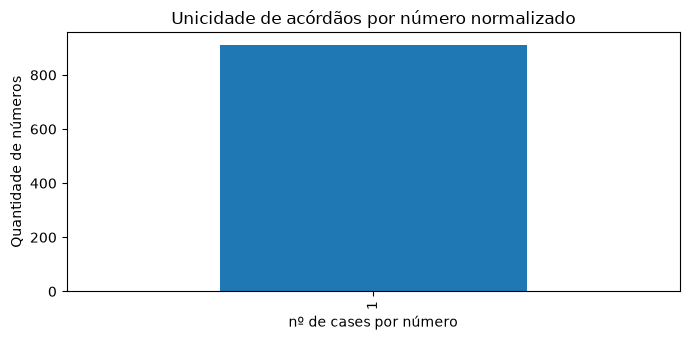

In [4]:
number_case_counts = pd.Series({number: sum(case.numero_normalizado == number for case in index.cases()) for number in case_by_number}, name='cases')
number_uniqueness = number_case_counts.value_counts().sort_index().rename_axis('nº de cases por número').reset_index(name='quantidade')
case_sizes = pd.DataFrame([{'tribunal': case.tribunal, 'candidate_ids': len(case.canonical_ids)} for case in index.cases()])
multi_cases = case_sizes.loc[case_sizes['candidate_ids'].gt(1)].copy()
multi_by_tribunal = multi_cases.groupby('tribunal', as_index=False).agg(cases=('candidate_ids', 'size'), max_ids=('candidate_ids', 'max'))
assert index.stats == {'records_total': 998, 'case_keys': 912, 'single_id_cases': 833, 'multi_id_cases': 79, 'max_ids_per_case': 4}

real_cases = results.loc[results['gold_class'].eq('real') & results['family'].isin(['processo_cnj', 'processo_ou_recurso_numerado'])].copy()
real_cases['multi_id_case'] = real_cases['candidate_ids'].map(lambda ids: len(ids) > 1)
print('CaseIndex:', index.stats)
display(number_uniqueness)
display(multi_by_tribunal)
display(real_cases.groupby('multi_id_case', as_index=False).size().rename(columns={'size': 'real citations'}))

fig, ax = plt.subplots(figsize=(7, 3.5))
number_uniqueness.plot.bar(x='nº de cases por número', y='quantidade', ax=ax, legend=False)
ax.set_title('Unicidade de acórdãos por número normalizado')
ax.set_ylabel('Quantidade de números')
plt.tight_layout()
plt.show()

## 5. Estados de resolução, recall e estratégias

`resolved_unique`, `no_match`, `ambiguous` e `insufficient` são estados neutros. A classe gold só é comparada nas tabelas seguintes. A estratégia legal é explicitamente experimental: o schema não armazena diploma, portanto artigo sozinho pode produzir unicidade acidental.

status,resolved_unique,no_match,ambiguous,insufficient
gold_class,,,,
real,75,2,3,16
inventada,1,51,0,12
incompleta,0,0,0,65


,family,real,gold ID among candidates,correct unique,ambiguous,unresolved,wrong unique,candidate recall %
0,jurisprudencia_referencia_geral,13,0,0,0,13,0,0.0
1,lei_dispositivo_com_diploma,13,13,13,0,0,0,100.0
2,lei_dispositivo_sem_diploma,1,0,0,0,1,0,0.0
3,processo_cnj,23,22,20,2,0,1,95.7
4,processo_ou_recurso_numerado,42,40,39,1,2,0,95.2
5,sumula_numerada,4,2,2,0,2,0,50.0


,family,sufficient_no_match,insufficient,ambiguous,unexpected_match
0,jurisprudencia_referencia_geral,0,10,0,0
1,lei_dispositivo_com_diploma,13,0,0,1
2,processo_cnj,2,0,0,0
3,processo_ou_recurso_numerado,32,0,0,0
4,sumula_numerada,4,2,0,0


,family,insufficient,ambiguous,unexpectedly_unique,no_match
0,jurisprudencia_referencia_geral,23,0,0,0
1,jurisprudencia_tribunal_contextual,20,0,0,0
2,lei_referencia_geral,11,0,0,0
3,processo_ou_recurso_numerado,11,0,0,0


,strategy,queries,correct real,no-match invented,false unique,ambiguous
0,case_number_exact,91,54,34,0,2
1,contextual_metadata,20,0,0,0,0
2,legal_article_frozen_corpus,27,13,13,1,0
3,legal_article_only,1,0,0,0,0
4,none,69,0,0,0,0
5,sumula_number_only,3,0,0,0,0
6,sumula_number_tribunal,7,2,4,0,0
7,tribunal_case_number,7,5,0,0,1


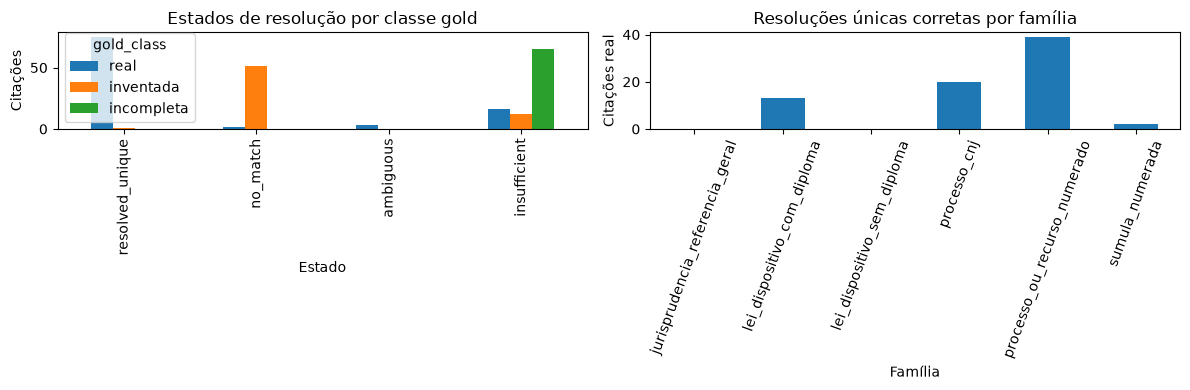

In [5]:
status_order = ['resolved_unique', 'no_match', 'ambiguous', 'insufficient']
resolution_matrix = pd.crosstab(results['gold_class'], results['status']).reindex(index=['real', 'inventada', 'incompleta'], columns=status_order, fill_value=0)
results['candidate_recall'] = results.apply(lambda row: row.gold_class == 'real' and row.gold_id in row.candidate_ids, axis=1)
results['correct_unique'] = results.apply(lambda row: row.gold_class == 'real' and row.status == 'resolved_unique' and row.resolved_id == row.gold_id, axis=1)
results['wrong_unique_real'] = results.apply(lambda row: row.gold_class == 'real' and row.status == 'resolved_unique' and row.resolved_id != row.gold_id, axis=1)
results['false_unique'] = results.apply(lambda row: row.gold_class != 'real' and row.status == 'resolved_unique', axis=1)

real_coverage = (results.loc[results.gold_class.eq('real')].groupby('family', as_index=False)
                 .agg(real=('gold_class', 'size'), **{'gold ID among candidates': ('candidate_recall', 'sum')},
                      **{'correct unique': ('correct_unique', 'sum')},
                      ambiguous=('status', lambda values: (values == 'ambiguous').sum()),
                      unresolved=('status', lambda values: values.isin(['no_match', 'insufficient']).sum()),
                      **{'wrong unique': ('wrong_unique_real', 'sum')}))
real_coverage['candidate recall %'] = (100 * real_coverage['gold ID among candidates'] / real_coverage['real']).round(1)

invented = (results.loc[results.gold_class.eq('inventada')].groupby('family', as_index=False)
            .agg(**{'sufficient_no_match': ('status', lambda values: (values == 'no_match').sum())},
                 insufficient=('status', lambda values: (values == 'insufficient').sum()),
                 ambiguous=('status', lambda values: (values == 'ambiguous').sum()),
                 unexpected_match=('status', lambda values: (values == 'resolved_unique').sum())))
incomplete = (results.loc[results.gold_class.eq('incompleta')].groupby('family', as_index=False)
              .agg(insufficient=('status', lambda values: (values == 'insufficient').sum()),
                   ambiguous=('status', lambda values: (values == 'ambiguous').sum()),
                   unexpectedly_unique=('status', lambda values: (values == 'resolved_unique').sum()),
                   no_match=('status', lambda values: (values == 'no_match').sum())))
strategy_table = (results.groupby('strategy', as_index=False)
                  .agg(queries=('citacao_id', 'size'), **{'correct real': ('correct_unique', 'sum')},
                       **{'no-match invented': ('gold_class', lambda values: 0)},
                       **{'false unique': ('false_unique', 'sum')},
                       ambiguous=('status', lambda values: (values == 'ambiguous').sum())))
strategy_table['no-match invented'] = strategy_table['strategy'].map(results.loc[(results.gold_class == 'inventada') & (results.status == 'no_match')].groupby('strategy').size()).fillna(0).astype(int)

display(resolution_matrix)
display(real_coverage)
display(invented)
display(incomplete)
display(strategy_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
resolution_matrix.T.plot.bar(ax=axes[0])
axes[0].set_title('Estados de resolução por classe gold')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Citações')
real_coverage.plot.bar(x='family', y='correct unique', ax=axes[1], legend=False)
axes[1].set_title('Resoluções únicas corretas por família')
axes[1].set_xlabel('Família')
axes[1].tick_params(axis='x', rotation=70)
axes[1].set_ylabel('Citações real')
plt.tight_layout()
plt.show()

## 6. Auditoria de erros, gaps de parser e classificação-oráculo

Os exemplos são exibidos depois da resolução. Em particular, a família jurisprudencial geral mantém seus 46 spans visíveis para separar identificadores textuais não extraídos pelo parser de lacunas semânticas/contextuais.

Classificação derivada (oracle, não end-to-end): 84.9%
Wrong unique em citações real: 1
False-real (gold inventada/incompleta resolvida): 1


,reason,count
0,parser_missing_identifier,14
1,unsupported_record_type,3
2,corpus_ambiguity,3
3,resolver_missing_strategy,2


,documento_id,citacao_id,family,gold_class,span,candidate_ids,resolved_id,strategy,reason
152,gen_n2_005,g6,processo_cnj,real,TST-AgARR-25823-78.2015.5.24.\n0091,"(1974934139,)",1.974934e+09,tribunal_case_number,structured_process_number
166,gen_n2_007,g2,lei_dispositivo_com_diploma,inventada,art 290 da Constituição\nFederal,"(10590194,)",1.059019e+07,legal_article_frozen_corpus,corpus_lacks_diploma_metadata


Todos os 46 casos de jurisprudência geral:


,documento_id,citacao_id,span,parsed_data,gold_class,gold_id,status,reason
20,gen_n1_003,g2,jurisprudência pacífica desta Corte,{},incompleta,NaN,insufficient,no_structured_identifier
23,gen_n1_003,g5,entendimento sumulado sobre a matéria,{},incompleta,NaN,insufficient,no_structured_identifier
35,gen_n1_005,g1,jurisprudência\npacífica desta Corte,{},incompleta,NaN,insufficient,no_structured_identifier
36,gen_n1_005,g2,precedentes desta Casa em situações análogas,{},incompleta,NaN,insufficient,no_structured_identifier
55,gen_n1_007,g4,RHC nº 55.508/RS,{},inventada,NaN,insufficient,parser_missing_identifier
62,gen_n1_008,g2,orientação jurisprudencial da Corte Superior,{},incompleta,NaN,insufficient,no_structured_identifier
67,gen_n1_008,g7,verbete sumular aplicável à espécie,{},incompleta,NaN,insufficient,no_structured_identifier
68,gen_n1_008,g8,orientação jurisprudencial da Corte Superior,{},incompleta,NaN,insufficient,no_structured_identifier
71,gen_n1_009,g1,Embargos de Declaração no Recurso em Mandado de Segurança\nnº 67.101/RJ,{},real,1.480059e+09,insufficient,parser_missing_identifier
74,gen_n1_009,g4,RHC 346037/PR,{},inventada,NaN,insufficient,parser_missing_identifier


Exemplos auditáveis:


,citacao_id,family,span,gold_class,status,candidate_ids,strategy,reason
5,g6,processo_cnj,APL nº\n7000449-40.2023.7.00.0000/RS,real,resolved_unique,"(5665364632,)",case_number_exact,structured_process_number
9,g10,processo_cnj,RSE nº 7000592-58.2025.7.00.0000/DF,real,resolved_unique,"(6689204911,)",case_number_exact,structured_process_number
13,g4,processo_ou_recurso_numerado,Recurso em Habeas Corpus nº 57.763/PR,real,resolved_unique,"(3576055165,)",case_number_exact,structured_process_number
2,g3,processo_ou_recurso_numerado,Reclamação nº 66.516/RO,inventada,no_match,(),case_number_exact,structured_process_number
7,g8,processo_ou_recurso_numerado,Rcl 88.178/RS,inventada,no_match,(),case_number_exact,structured_process_number
197,g7,processo_ou_recurso_numerado,AgInt no Recurso Especial nº 1.597.443\n- PR,real,ambiguous,"(2679428592, 2684973273)",case_number_exact,structured_process_number
0,g1,lei_referencia_geral,normas\nde regência da matéria,incompleta,insufficient,(),none,unsupported_family
1,g2,jurisprudencia_tribunal_contextual,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,incompleta,insufficient,(),contextual_metadata,not_primary_identity
4,g5,jurisprudencia_tribunal_contextual,julgado do STM proferido em 2023\npela relatoria de CARLOS AUGUSTO AMARAL OLIVEIRA,incompleta,insufficient,(),contextual_metadata,not_primary_identity


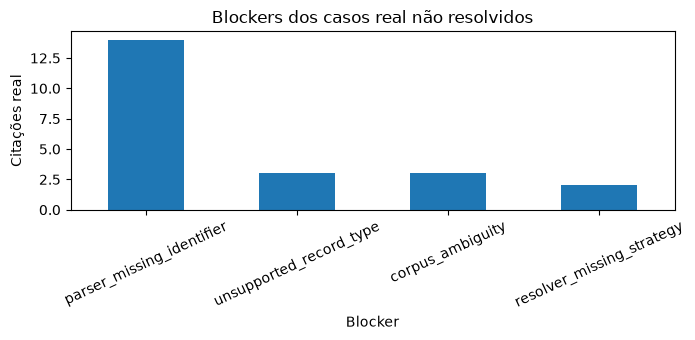

,nivel,real,correct_unique,wrong_unique,ambiguous,insufficient
0,N1,52,44,0,2,5
1,N2,44,30,1,1,11


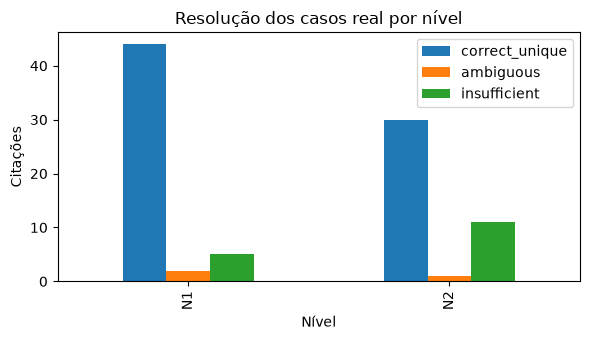

In [6]:
def real_blocker(row) -> str | None:
    if row.gold_class != 'real' or row.correct_unique:
        return None
    if row.status == 'ambiguous':
        return 'corpus_ambiguity'
    if row.reason in {'missing_process_number', 'parser_missing_identifier', 'missing_sumula_number'}:
        return 'parser_missing_identifier'
    if row.family in {'sumula_numerada', 'lei_dispositivo_sem_diploma'}:
        return 'unsupported_record_type'
    if row.family in {'jurisprudencia_referencia_geral', 'jurisprudencia_tribunal_contextual'}:
        return 'other_context_or_semantic_gap'
    return 'resolver_missing_strategy'

results['blocker'] = results.apply(real_blocker, axis=1)
blockers = results.loc[results.blocker.notna(), 'blocker'].value_counts().rename_axis('reason').reset_index(name='count')
wrong_unique = results.loc[results.false_unique | results.wrong_unique_real, ['documento_id', 'citacao_id', 'family', 'gold_class', 'span', 'candidate_ids', 'resolved_id', 'strategy', 'reason']]
general_audit = results.loc[results.family.eq('jurisprudencia_referencia_geral'), ['documento_id', 'citacao_id', 'span', 'parsed_data', 'gold_class', 'gold_id', 'status', 'reason']]
examples = pd.concat([
    results.loc[results.correct_unique].head(3),
    results.loc[(results.gold_class == 'inventada') & (results.status == 'no_match')].head(3),
    results.loc[results.status == 'ambiguous'].head(3),
    results.loc[results.status == 'insufficient'].head(3),
    results.loc[results.reason == 'parser_missing_identifier'].head(3),
]).drop_duplicates('citacao_id')

classification_map = {'resolved_unique': 'real', 'no_match': 'inventada', 'ambiguous': 'incompleta', 'insufficient': 'incompleta'}
results['derived_class'] = results.status.map(classification_map)
oracle_accuracy = (results.derived_class == results.gold_class).mean()
print(f'Classificação derivada (oracle, não end-to-end): {oracle_accuracy:.1%}')
print('Wrong unique em citações real:', int(results.wrong_unique_real.sum()))
print('False-real (gold inventada/incompleta resolvida):', int(results.false_unique.sum()))
display(blockers)
display(wrong_unique)
print('Todos os 46 casos de jurisprudência geral:')
display(general_audit)
print('Exemplos auditáveis:')
display(examples[['citacao_id', 'family', 'span', 'gold_class', 'status', 'candidate_ids', 'strategy', 'reason']])

fig, ax = plt.subplots(figsize=(7, 3.5))
blockers.plot.bar(x='reason', y='count', ax=ax, legend=False)
ax.set_title('Blockers dos casos real não resolvidos')
ax.set_xlabel('Blocker')
ax.set_ylabel('Citações real')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

n1_n2 = (results.loc[results.gold_class.eq('real')].groupby('nivel', as_index=False)
         .agg(real=('gold_class', 'size'), correct_unique=('correct_unique', 'sum'),
              wrong_unique=('wrong_unique_real', 'sum'), ambiguous=('status', lambda values: (values == 'ambiguous').sum()),
              insufficient=('status', lambda values: (values == 'insufficient').sum())))
display(n1_n2)
fig, ax = plt.subplots(figsize=(6, 3.5))
n1_n2.set_index('nivel')[['correct_unique', 'ambiguous', 'insufficient']].plot.bar(ax=ax)
ax.set_title('Resolução dos casos real por nível')
ax.set_xlabel('Nível')
ax.set_ylabel('Citações')
plt.tight_layout()
plt.show()

## 7. Suficiência, determinismo, risco e contrato proposto

A unicidade acidental no corpus congelado não vira suficiência semântica. Portanto, a estratégia legal por artigo é mantida somente como teste de risco, e não como proposta de produção.

In [7]:
snapshots = []
started = time.perf_counter()
for _ in range(3):
    rerun = build_results()
    snapshots.append(tuple(rerun.assign(resolved_id=rerun['resolved_id'].fillna(-1).astype(int))[['status', 'candidate_ids', 'resolved_id', 'strategy']].itertuples(index=False, name=None)))
elapsed_ms = (time.perf_counter() - started) * 1000
assert snapshots[0] == snapshots[1] == snapshots[2]

sufficiency_rules = pd.DataFrame([
    ('processo_cnj', 'número CNJ', 'suficiente', 'CNJ exact / tribunal+CNJ quando explícito'),
    ('processo_ou_recurso_numerado', 'número processual', 'suficiente', 'número exato; preservar multi-ID como ambíguo'),
    ('sumula_numerada', 'número + tribunal', 'suficiente', 'sem tribunal permanece insuficiente'),
    ('lei_dispositivo_com_diploma', 'artigo + diploma', 'suficiente conceitualmente', 'schema atual não possui diploma estruturado'),
    ('lei_dispositivo_sem_diploma', 'somente artigo', 'insuficiente', 'unicidade local não prova suficiência'),
    ('jurisprudencia_tribunal_contextual', 'tribunal + relator + ano', 'insuficiente', 'metadados não são identidade primária'),
    ('jurisprudencia_referencia_geral', 'nenhum campo estruturado', 'insuficiente', 'identificadores textuais são parser gaps'),
], columns=['family', 'estrutura', 'suficiência', 'observação'])
risk_table = pd.DataFrame([
    ('cnj_exact', 'número oficial', '20 correct; 1 wrong; 2 ambiguous; 2 no-match', 'MEDIUM', 'MEDIUM'),
    ('case_number_exact', 'CaseIndex por número', '39 unique; multi-ID preservado', 'LOW', 'LOW'),
    ('tribunal_case_number', 'CaseIndex por tribunal+número', '5 correct; 1 wrong; 1 ambiguous', 'MEDIUM', 'MEDIUM'),
    ('sumula_number_tribunal', 'número e tribunal', '2 unique; docs sem número estruturado limitam recall', 'MEDIUM', 'LOW'),
    ('legal_article_frozen_corpus', 'artigo sem diploma no schema', '13 real unique; 1 false-real', 'HIGH', 'HIGH'),
    ('contextual_metadata', 'tribunal, relator, ano', 'sempre insuficiente no probe', 'LOW', 'HIGH'),
], columns=['strategy', 'support', 'resultados', 'complexity', 'generalization risk'])

print(f'Três execuções idênticas; {elapsed_ms:.1f} ms para 3 × 225 probes.')
display(sufficiency_rules)
display(risk_table)
print('Contrato mínimo conceitual (não implementado):')
print('ResolutionResult(status, id_canonico, candidate_ids, strategy, reason, record_type)')
print('Arquitetura recomendada: um CitationResolver com dispatch interno por family/record_type; CaseIndex + pequenos mappings read-only para súmulas/dispositivos quando o schema fornecer identidade suficiente.')

Três execuções idênticas; 30.6 ms para 3 × 225 probes.


,family,estrutura,suficiência,observação
0,processo_cnj,número CNJ,suficiente,CNJ exact / tribunal+CNJ quando explícito
1,processo_ou_recurso_numerado,número processual,suficiente,número exato; preservar multi-ID como ambíguo
2,sumula_numerada,número + tribunal,suficiente,sem tribunal permanece insuficiente
3,lei_dispositivo_com_diploma,artigo + diploma,suficiente conceitualmente,schema atual não possui diploma estruturado
4,lei_dispositivo_sem_diploma,somente artigo,insuficiente,unicidade local não prova suficiência
5,jurisprudencia_tribunal_contextual,tribunal + relator + ano,insuficiente,metadados não são identidade primária
6,jurisprudencia_referencia_geral,nenhum campo estruturado,insuficiente,identificadores textuais são parser gaps


,strategy,support,resultados,complexity,generalization risk
0,cnj_exact,número oficial,20 correct; 1 wrong; 2 ambiguous; 2 no-match,MEDIUM,MEDIUM
1,case_number_exact,CaseIndex por número,39 unique; multi-ID preservado,LOW,LOW
2,tribunal_case_number,CaseIndex por tribunal+número,5 correct; 1 wrong; 1 ambiguous,MEDIUM,MEDIUM
3,sumula_number_tribunal,número e tribunal,2 unique; docs sem número estruturado limitam recall,MEDIUM,LOW
4,legal_article_frozen_corpus,artigo sem diploma no schema,13 real unique; 1 false-real,HIGH,HIGH
5,contextual_metadata,"tribunal, relator, ano",sempre insuficiente no probe,LOW,HIGH


Contrato mínimo conceitual (não implementado):
ResolutionResult(status, id_canonico, candidate_ids, strategy, reason, record_type)
Arquitetura recomendada: um CitationResolver com dispatch interno por family/record_type; CaseIndex + pequenos mappings read-only para súmulas/dispositivos quando o schema fornecer identidade suficiente.


## 8. Findings e decisão

- A análise é um upper bound de resolução com spans-oráculo e `CitationParser` V1; não é end-to-end.
- `CaseIndex` permite estratégias estruturais de baixo risco por número, mas grupos multi-ID permanecem ambíguos e nunca autorizam escolha arbitrária.
- A resolução por artigo isolado produz pelo menos um false-real: o schema não registra diploma, portanto essa estratégia não é segura para produção.
- Referências jurisprudenciais gerais com número que o parser não extrai são gaps do parser, não convite a busca textual ad hoc.
- FTS não foi utilizado: busca no corpo não é identidade documental.

**Decisão: C) realizar outra rodada exploratória de resolution.** Há um `wrong_unique` de CNJ TST: o número do span resolve de modo único para `doc_0729`, enquanto o gold aponta `doc_0710`. Como o contrato exige o ID escalar exato, o descompasso precisa ser investigado sem usar o gold para orientar a busca. Além disso, a estratégia legal por artigo gera um false-real porque o schema não expõe diploma verificável. Nenhum `CitationResolver` será implementado antes de esclarecer esses dois riscos.